In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [16]:
fname = '../../../../../Data/Animal_Trajectory_Data/crabs/crab_105N_vx.csv'
df_raw_vx = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_105N_vx.csv')
df_raw_vy = pd.read_csv('../../../../../Data/Animal_Trajectory_Data/crabs/crab_105N_vy.csv')
flow_direction = np.pi

flow_condition = 'laminar'
flow_speed = 0.05
body_length = 0.1
locomotion = 'walking'
medium = 'water'
group = 'aquatic'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [4]:
# drop backwards times

ix_vx_drop = np.where(np.diff(df_raw_vx.time.values)<0)[0]
df_raw_vx = df_raw_vx.drop(ix_vx_drop)

ix_vy_drop = np.where(np.diff(df_raw_vy.time.values)<0)[0]
df_raw_vy = df_raw_vy.drop(ix_vy_drop)

In [5]:
interp_timestamps_sec = np.arange(df_raw_vx.time.min(), df_raw_vx.time.max(), 0.1)

In [6]:
spline_x = UnivariateSpline(df_raw_vx.time, df_raw_vx.xvel, s=2, k=3)  # s=smoothing amount
interp_vx = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_raw_vy.time, df_raw_vy.yvel, s=2, k=3)  # s=smoothing amount
interp_vy = spline_y(interp_timestamps_sec)

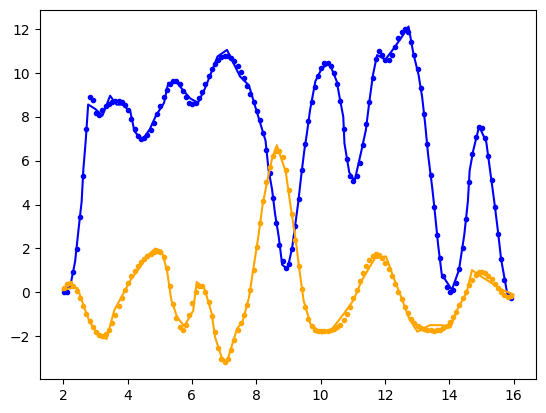

In [7]:
plt.plot(df_raw_vx.time.values, df_raw_vx.xvel.values, color='blue')
plt.plot(interp_timestamps_sec, interp_vx, '.', color='blue')


plt.plot(df_raw_vy.time.values, df_raw_vy.yvel.values, color='orange')
plt.plot(interp_timestamps_sec, interp_vy, '.', color='orange')

In [8]:
dt = np.median(np.diff(interp_timestamps_sec))
x = np.cumsum(interp_vx*dt)
y = np.cumsum(interp_vy*dt)

In [9]:
df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': x,
                                     'y': y,
                                     'xvel': interp_vx,
                                     'yvel': interp_vy})

### Parameters

In [10]:
df_calibrated_interp.shape

(140, 5)

In [11]:
tix_start = 20
tix_end = 135

4.018445322800002


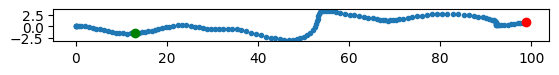

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

#ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [14]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [17]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

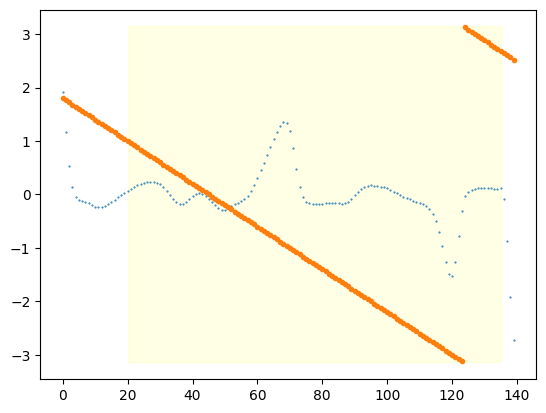

In [18]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [19]:
min_ix_range = 30
max_ix_range = 50

In [20]:
trajec = df_calibrated_interp

In [21]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [22]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [23]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Set parameter Username
Set parameter LicenseID to value 2753061
Academic license - for non-commercial use only - expires 2026-12-11


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [24]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [25]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [26]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
9,73,108,0.004468,-6.714285,3.104592,2.429580,-1.506598,-2.424193,0.145508,0.145508,...,9,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
8,90,121,-0.045892,4.597138,-2.998307,1.673285,0.742378,1.654303,0.131567,0.131567,...,8,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
7,39,70,0.048919,-2.395041,2.634170,1.285122,0.591261,1.121285,-0.294682,-0.294682,...,7,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
0,86,121,-0.031187,-3.284509,-3.079082,2.294577,0.772674,2.288637,0.094888,0.094888,...,0,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
5,29,69,0.018062,5.532309,3.089146,4.544446,1.030486,4.534789,-0.183958,-0.183958,...,5,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
3,27,73,0.023351,-0.955355,2.717713,1.526446,0.594312,1.368759,-0.349457,-0.349457,...,3,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
1,34,75,0.029548,-1.396396,2.122658,1.100404,0.259327,0.490508,-0.375495,-0.375495,...,1,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
6,33,79,0.035905,-1.660924,1.956911,0.532784,-0.129386,-0.035476,-0.231009,-0.231009,...,6,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
4,40,89,-0.000657,-6.285628,3.096201,3035.149059,0.738305,-3028.901320,137.546972,137.546972,...,4,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic
2,40,82,0.006316,-6.602366,3.226949,30.914417,-1.313690,-30.680182,-2.737534,-2.737534,...,2,crab_105N_vx,0.099,3.141593,laminar,0.05,0.1,walking,water,aquatic


In [27]:
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

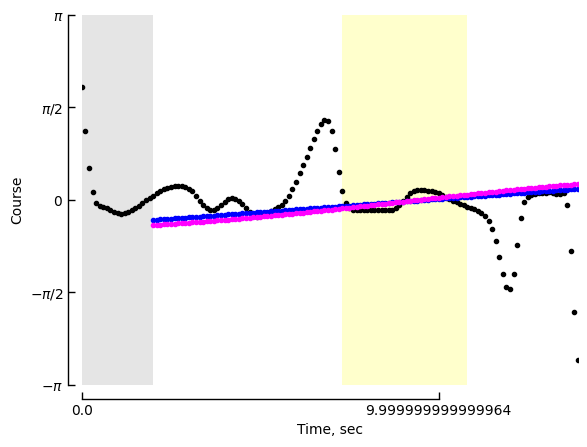

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [29]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')